# Task 1: Character-level GPT on TinyStories

Runs `train_char_gpt.py` (config: `char_gpt_config.json`) and shows every result inline.
The full run takes 1-2 hours on the GPU, so training is off by default: run the script from a terminal,
then run this notebook to display the results.

In [ ]:
import sys
print("Python", sys.version.split()[0])
!nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv

## 1. Train (optional)

In [2]:
RUN_TRAINING = False
if RUN_TRAINING:
    !"{sys.executable}" train_char_gpt.py

In [3]:
import csv, json
from pathlib import Path
from IPython.display import Image, Markdown, display

MEMBER_DIR = Path.cwd().parent          # notebook lives in <task>/<member>/src/
OUT = MEMBER_DIR / "outputs"


def fmt(value):
    try:
        number = float(value)
    except ValueError:
        return value
    return value if number.is_integer() and "." not in value else f"{number:.4g}"


def show_csv(path, transpose=False):
    rows = list(csv.reader(open(path, encoding="utf-8")))
    if transpose:
        rows = [list(column) for column in zip(*rows)]
    lines = ["| " + " | ".join(rows[0]) + " |", "|" + "---|" * len(rows[0])]
    lines += ["| " + " | ".join(fmt(v) for v in row) + " |" for row in rows[1:]]
    display(Markdown("\n".join(lines)))

## 2. Loss curves and training stability

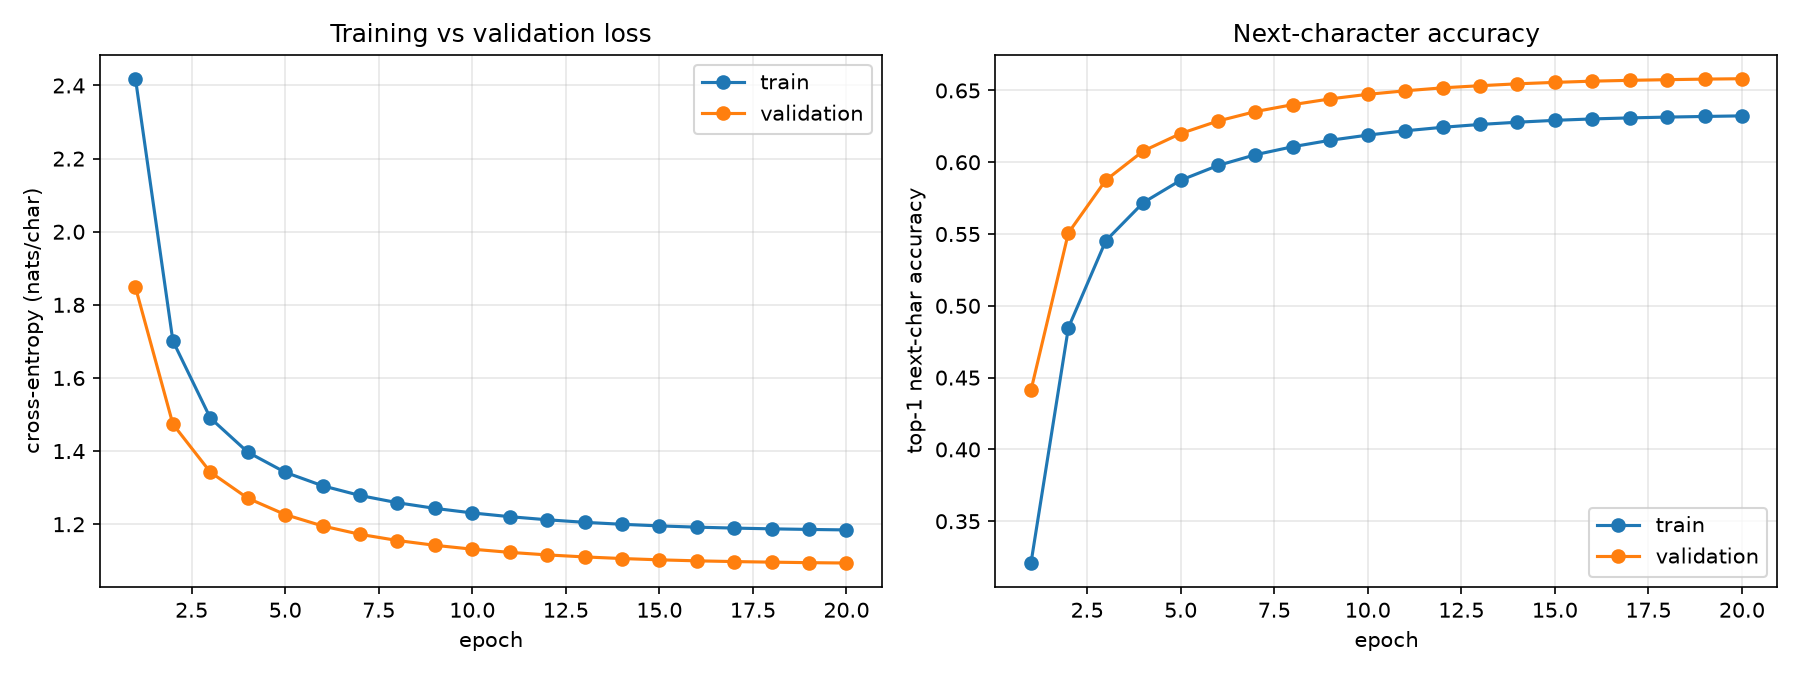

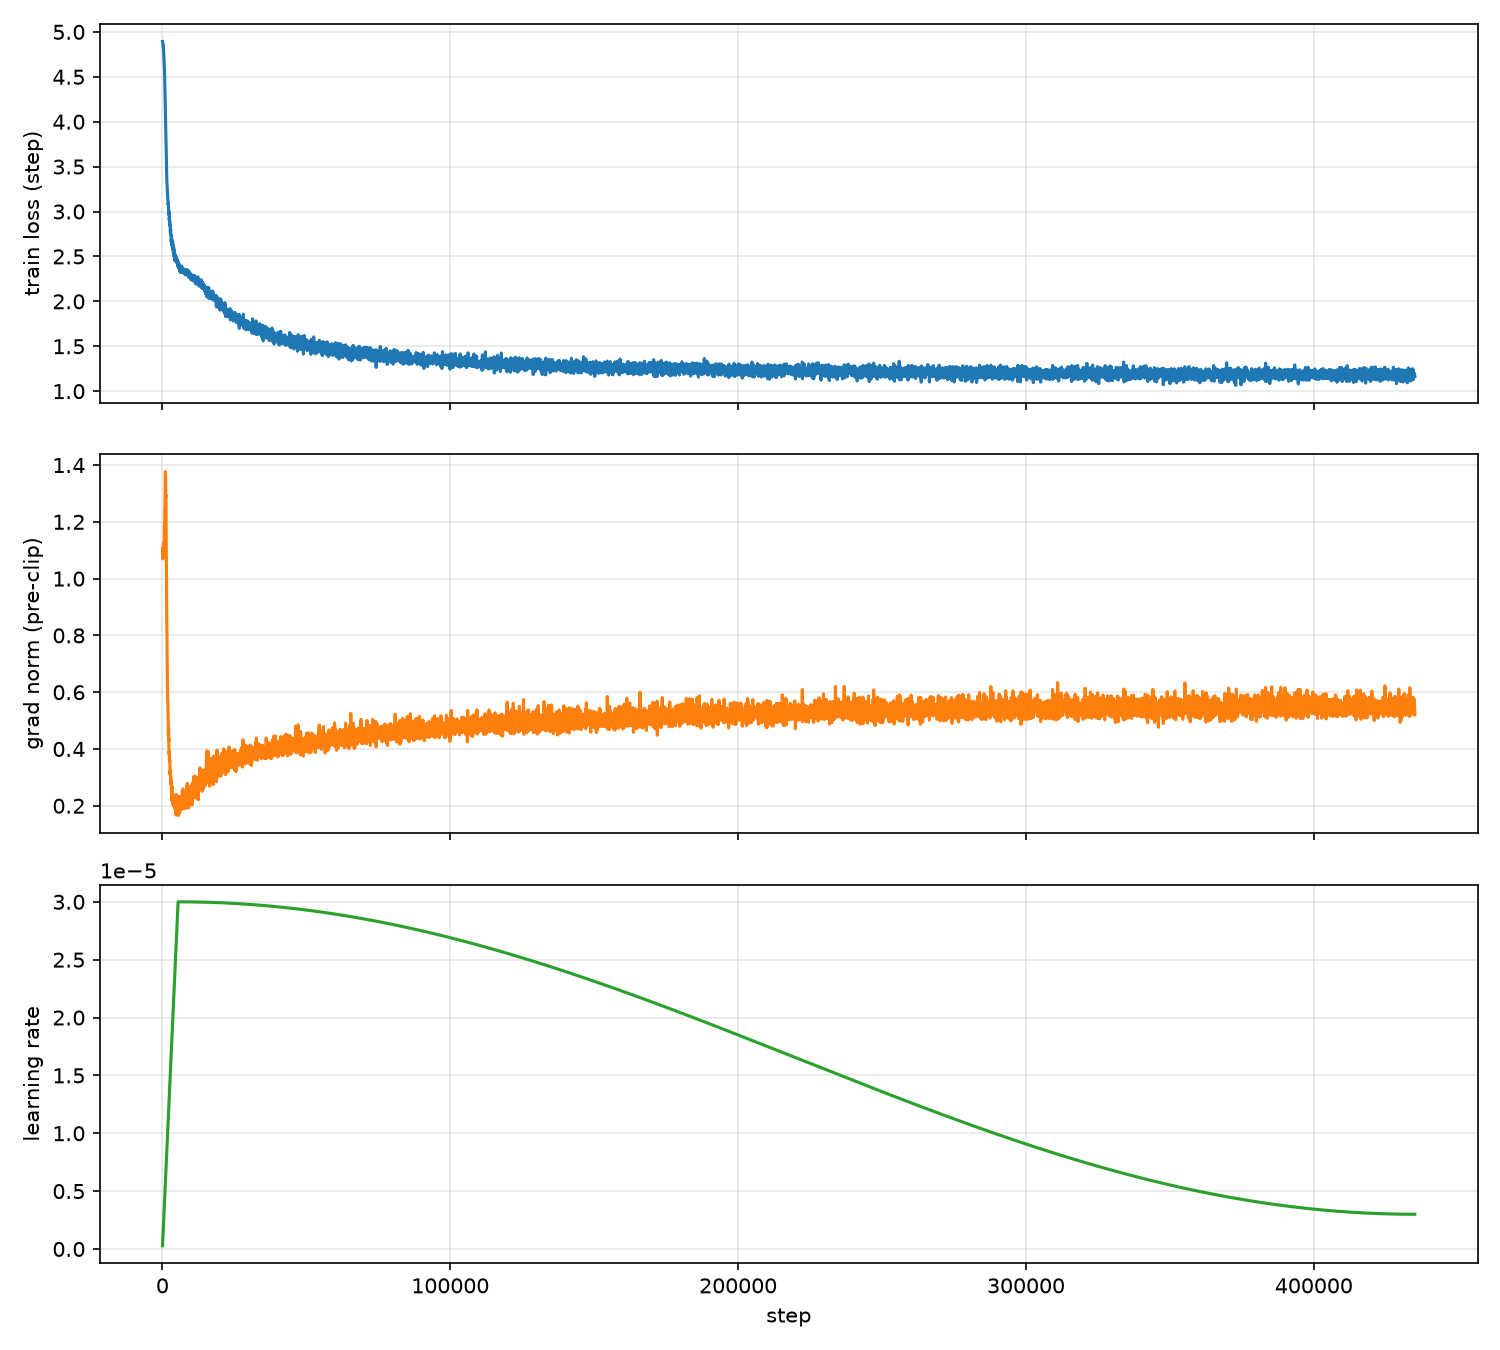

In [4]:
display(Image(OUT / "loss_curves.png"))
display(Image(OUT / "training_dynamics.png"))

## 3. Per-epoch history

In [5]:
show_csv(OUT / "epoch_history.csv")

| epoch | train_loss | val_loss | train_ppl | val_ppl | train_bpc | val_bpc | generalization_gap | train_accuracy | val_accuracy | grad_norm_mean | grad_norm_max | loss_spikes | nan_steps | lr_end | epoch_seconds | train_tokens_per_sec |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 2.419 | 1.848 | 11.23 | 6.347 | 3.489 | 2.666 | -0.5705 | 0.3209 | 0.4412 | 0.3469 | 1.41 | 0 | 0 | 2.99e-05 | 332.5 | 2.68e+05 |
| 2 | 1.701 | 1.474 | 5.481 | 4.366 | 2.455 | 2.126 | -0.2275 | 0.4848 | 0.5508 | 0.383 | 0.4974 | 0 | 0 | 2.948e-05 | 361.7 | 2.464e+05 |
| 3 | 1.491 | 1.343 | 4.439 | 3.829 | 2.15 | 1.937 | -0.148 | 0.5453 | 0.5875 | 0.4284 | 0.5574 | 0 | 0 | 2.873e-05 | 363.6 | 2.451e+05 |
| 4 | 1.397 | 1.271 | 4.044 | 3.565 | 2.016 | 1.834 | -0.126 | 0.5719 | 0.6078 | 0.4558 | 0.5633 | 0 | 0 | 2.767e-05 | 368.2 | 2.42e+05 |
| 5 | 1.342 | 1.226 | 3.827 | 3.409 | 1.936 | 1.769 | -0.1156 | 0.5875 | 0.62 | 0.475 | 0.5975 | 0 | 0 | 2.633e-05 | 364.6 | 2.444e+05 |
| 6 | 1.305 | 1.195 | 3.688 | 3.304 | 1.883 | 1.724 | -0.1099 | 0.5978 | 0.6287 | 0.4895 | 0.6937 | 0 | 0 | 2.474e-05 | 368.3 | 2.42e+05 |
| 7 | 1.279 | 1.172 | 3.592 | 3.23 | 1.845 | 1.691 | -0.1062 | 0.6053 | 0.6353 | 0.5009 | 0.6276 | 0 | 0 | 2.294e-05 | 4867 | 1.831e+04 |
| 8 | 1.259 | 1.155 | 3.521 | 3.176 | 1.816 | 1.667 | -0.1033 | 0.6108 | 0.6401 | 0.5099 | 0.6461 | 0 | 0 | 2.098e-05 | 338.8 | 2.63e+05 |
| 9 | 1.243 | 1.142 | 3.467 | 3.134 | 1.794 | 1.648 | -0.101 | 0.6153 | 0.6441 | 0.5178 | 0.6519 | 0 | 0 | 1.89e-05 | 350.6 | 2.542e+05 |
| 10 | 1.231 | 1.132 | 3.424 | 3.101 | 1.776 | 1.633 | -0.09914 | 0.6189 | 0.6473 | 0.5249 | 0.6719 | 0 | 0 | 1.677e-05 | 345.6 | 2.578e+05 |
| 11 | 1.221 | 1.123 | 3.389 | 3.074 | 1.761 | 1.62 | -0.09758 | 0.6219 | 0.6497 | 0.5298 | 0.7406 | 0 | 0 | 1.463e-05 | 347.3 | 2.566e+05 |
| 12 | 1.212 | 1.116 | 3.361 | 3.053 | 1.749 | 1.61 | -0.0961 | 0.6243 | 0.6518 | 0.5343 | 0.7159 | 0 | 0 | 1.253e-05 | 354.6 | 2.513e+05 |
| 13 | 1.205 | 1.111 | 3.338 | 3.036 | 1.739 | 1.602 | -0.09465 | 0.6263 | 0.6533 | 0.5383 | 0.7547 | 0 | 0 | 1.054e-05 | 352 | 2.532e+05 |
| 14 | 1.2 | 1.106 | 3.32 | 3.023 | 1.731 | 1.596 | -0.09365 | 0.6279 | 0.6546 | 0.5411 | 0.7054 | 0 | 0 | 8.696e-06 | 355.5 | 2.506e+05 |
| 15 | 1.195 | 1.103 | 3.305 | 3.012 | 1.725 | 1.591 | -0.0928 | 0.6292 | 0.6556 | 0.5433 | 0.7216 | 0 | 0 | 7.049e-06 | 353.6 | 2.52e+05 |
| 16 | 1.192 | 1.1 | 3.294 | 3.004 | 1.72 | 1.587 | -0.09211 | 0.6302 | 0.6565 | 0.5449 | 0.6834 | 0 | 0 | 5.642e-06 | 353.4 | 2.522e+05 |
| 17 | 1.189 | 1.098 | 3.285 | 2.998 | 1.716 | 1.584 | -0.09155 | 0.6309 | 0.6571 | 0.5464 | 0.7033 | 0 | 0 | 4.508e-06 | 354.6 | 2.513e+05 |
| 18 | 1.187 | 1.096 | 3.279 | 2.993 | 1.713 | 1.582 | -0.09113 | 0.6314 | 0.6575 | 0.5473 | 0.6962 | 0 | 0 | 3.677e-06 | 357.7 | 2.492e+05 |
| 19 | 1.186 | 1.095 | 3.273 | 2.989 | 1.711 | 1.58 | -0.09084 | 0.6319 | 0.6579 | 0.5478 | 0.7311 | 0 | 0 | 3.17e-06 | 355.5 | 2.507e+05 |
| 20 | 1.184 | 1.094 | 3.269 | 2.986 | 1.709 | 1.578 | -0.09055 | 0.6323 | 0.6582 | 0.5484 | 0.7796 | 0 | 0 | 3e-06 | 354.1 | 2.517e+05 |

## 4. Full metrics report

In [6]:
show_csv(MEMBER_DIR / "metrics_report.csv")

| metric | value | notes |
|---|---|---|
| best_epoch | 20 | checkpoint: checkpoints/best.pt |
| epochs_run | 20 |  |
| train_cross_entropy | 1.184 | nats/char, running mean over the epoch (dropout on) |
| val_cross_entropy | 1.094 | nats/char |
| val_perplexity | 2.986 | exp(val CE) |
| train_perplexity | 3.269 | exp(train CE) |
| val_bits_per_char | 1.578 | val CE / ln 2 |
| train_bits_per_char | 1.709 | train CE / ln 2 |
| generalization_gap | -0.09055 | val CE - train CE |
| val_top1_accuracy | 0.6582 | next-character |
| train_top1_accuracy | 0.6323 | next-character |
| grad_norm_mean_all_epochs | 0.5027 | pre-clip L2 norm |
| grad_norm_max_all_epochs | 1.41 | pre-clip L2 norm |
| loss_spikes_total | 0 | step loss > spike_factor x EMA |
| nan_steps_total | 0 | non-finite loss or grad (step skipped) |
| parameter_count | 257869 |  |
| train_tokens_per_sec_mean | 2.4e+05 |  |
| total_training_seconds | 1.17e+04 | includes validation passes |
| gpu_peak_allocated_mb | 147.1 |  |
| cpu_peak_rss_mb | 3986 |  |
| greedy_distinct_1 | 0.08807 | word-level, pooled over prompts |
| greedy_distinct_2 | 0.1182 | word-level, pooled over prompts |
| greedy_distinct_3 | 0.1374 | word-level, pooled over prompts |
| greedy_repeated_4gram_rate | 0.7031 | word-level, mean over samples |
| greedy_generation_tokens_per_sec | 257.3 | batch size 1 |
| temp_0.8_distinct_1 | 0.5566 | word-level, pooled over prompts |
| temp_0.8_distinct_2 | 0.9393 | word-level, pooled over prompts |
| temp_0.8_distinct_3 | 0.9935 | word-level, pooled over prompts |
| temp_0.8_repeated_4gram_rate | 0 | word-level, mean over samples |
| temp_0.8_generation_tokens_per_sec | 236.9 | batch size 1 |
| temp_1.0_top20_distinct_1 | 0.6044 | word-level, pooled over prompts |
| temp_1.0_top20_distinct_2 | 0.955 | word-level, pooled over prompts |
| temp_1.0_top20_distinct_3 | 1 | word-level, pooled over prompts |
| temp_1.0_top20_repeated_4gram_rate | 0 | word-level, mean over samples |
| temp_1.0_top20_generation_tokens_per_sec | 239 | batch size 1 |
| hardware | NVIDIA GeForce RTX 3080 Ti Laptop GPU | cuda |

## 5. Generated samples
Failure cases are written in `../failure_analysis.md` (candidates: `../outputs/failure_candidates.md`).

In [7]:
for s in json.load(open(OUT / "samples.json", encoding="utf-8")):
    print(f"[{s['decoding']}] repeated-4gram={s['repeated_4gram_rate']:.3f}")
    print(s["prompt"] + s["generated"], "\n")

[greedy] repeated-4gram=0.582
Once upon a time, there was a little girl named Lily. She was so happy to help her mom and said, "I want to the big ball and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I wa 

[greedy] repeated-4gram=0.706
One day, a little girl named Lily. She was so happy to help her mom and said, "I want to the bear and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I want to the  

[greedy] repeated-4gram=0.765
The dog was very happy because he was so happy to the ball and said, "I want to the ball and said, "I want to the bear and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I want to the ball and said, "I wan